In [203]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [204]:
from asrl.open3d_tests.env_builder import *
from asrl.slam.icp import *
from asrl.slam.slam_gtsam import *
from spatialmath import SE2

In [205]:
og = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 1, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1],
    [0, 1, 1, 1, 0, 1, 0, 1],
    [0, 0, 1, 1, 1, 1, 0, 1],
    [0, 0, 1, 0, 0, 1, 0, 1],
    [0, 0, 1, 0, 0, 1, 1, 1],
    [0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 1, 0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0, 1, 0, 0],
    [0, 0, 1, 1, 1, 1, 0, 0],
])

m = ArrayMap(og, scale=1)

m.to_o3d_geometry()
scene = o3d.t.geometry.RaycastingScene()
walls = m.to_o3d_geometry()
for cube in walls:
    scene.add_triangles(o3d.t.geometry.TriangleMesh.from_legacy(cube))

[[0 0 1 1 1 1 1 0 0]
 [1 1 1 0 0 0 1 1 1]
 [1 0 0 0 1 0 0 0 1]
 [1 0 0 0 1 0 1 0 1]
 [1 1 0 0 0 0 1 0 1]
 [0 1 0 1 1 0 1 0 1]
 [0 1 0 1 1 0 0 0 1]
 [0 1 0 0 0 0 1 1 1]
 [0 1 0 1 1 0 1 0 0]
 [0 1 0 1 1 0 1 0 0]
 [0 1 0 0 0 0 1 0 0]
 [0 1 1 1 1 1 1 0 0]]


In [206]:
# poses = np.array([
#     [2.5, 1.5, 0],
#     [2.5, 1.65, 0.8],
#     [2.5, 1.8, 1.2],
#     [2.5, 2.0, 1.5],
#     [2.3, 2.3, 1.6],
#     [2.3, 2.5, 1.6],
#     [2.3, 2.8, 1.6],
#     [2.3, 3.0, 1.6],
# ])

poses = [
    [2.5, 1.5, 0],
]

for y in np.linspace(1.5, 4.5, 20):
    poses.append([2.5 + np.random.uniform(-0.1, 0.1), y + np.random.uniform(-0.1, 0.1), np.random.uniform(-0.3, 0.3)])

for x in np.linspace(2.5, 5.5, 20):
    poses.append([x + np.random.uniform(-0.1, 0.1), 4.5 + np.random.uniform(-0.1, 0.1), np.random.uniform(-0.3, 0.3)])

for y in np.linspace(4.5, 1.5, 20):
    poses.append([5.5 + np.random.uniform(-0.1, 0.1), y + np.random.uniform(-0.1, 0.1), np.random.uniform(-0.3, 0.3)])

for x in np.linspace(5.5, 2.5, 20):
    poses.append([x + np.random.uniform(-0.1, 0.1), 1.5 + np.random.uniform(-0.1, 0.1), np.random.uniform(-0.3, 0.3)])

for y in np.linspace(1.5, 7.5, 20):
    poses.append([2.5 + np.random.uniform(-0.1, 0.1), y + np.random.uniform(-0.1, 0.1), np.random.uniform(-0.3, 0.3)])

for x in np.linspace(2.5, 5.5, 20):
    poses.append([x + np.random.uniform(-0.1, 0.1), 7.5 + np.random.uniform(-0.1, 0.1), np.random.uniform(-0.3, 0.3)])

for y in np.linspace(7.5, 4.5, 20):
    poses.append([5.5 + np.random.uniform(-0.1, 0.1), y + np.random.uniform(-0.1, 0.1), np.random.uniform(-0.3, 0.3)])

for y in np.linspace(4.5, 5.5, 20):
    poses.append([5.5 + np.random.uniform(-0.1, 0.1), y + np.random.uniform(-0.1, 0.1), np.random.uniform(-0.3, 0.3)])

for x in np.linspace(5.5, 7.5, 20):
    poses.append([x + np.random.uniform(-0.1, 0.1), 5.5 + np.random.uniform(-0.1, 0.1), np.random.uniform(-0.3, 0.3)])

for y in np.linspace(5.5, 9.5, 20):
    poses.append([7.5 + np.random.uniform(-0.1, 0.1), y + np.random.uniform(-0.1, 0.1), np.random.uniform(-0.3, 0.3)])

for x in np.linspace(7.5, 5.5, 20):
    poses.append([x + np.random.uniform(-0.1, 0.1), 9.5 + np.random.uniform(-0.1, 0.1), np.random.uniform(-0.3, 0.3)])

for y in np.linspace(9.5, 7.5, 20):
    poses.append([5.5 + np.random.uniform(-0.1, 0.1), y + np.random.uniform(-0.1, 0.1), np.random.uniform(-0.3, 0.3)])

for y in np.linspace(7.5, 10.5, 20):
    poses.append([5.5 + np.random.uniform(-0.1, 0.1), y + np.random.uniform(-0.1, 0.1), np.random.uniform(-0.3, 0.3)])

for x in np.linspace(5.5, 3.5, 20):
    poses.append([x + np.random.uniform(-0.1, 0.1), 10.5 + np.random.uniform(-0.1, 0.1), np.random.uniform(-0.3, 0.3)])

for y in np.linspace(10.5, 7.5, 20):
    poses.append([3.5 + np.random.uniform(-0.1, 0.1), y + np.random.uniform(-0.1, 0.1), np.random.uniform(-0.3, 0.3)])

poses = np.array(poses)

scans = collect_body_lidar_scans(poses, scene)

A = scans[3][:, :2]
B = scans[4][:, :2]

T, _, _ = icp(A, B, max_dist=1.0)

A_new = (np.c_[A, np.ones(A.shape[0])] @ SE2(T).A.T)[:, :2]

# plt.gca().set_aspect('equal')
# plt.scatter(A[:,0], A[:,1], c='r')
# plt.scatter(B[:, 0], B[:, 1], c='b')
# plt.scatter(A[:, 0], A[:, 1], c='r')
# plt.scatter(A_new[:, 0], A_new[:, 1], c='g')

added loop closure
added loop closure
added loop closure
added loop closure
added loop closure
added loop closure


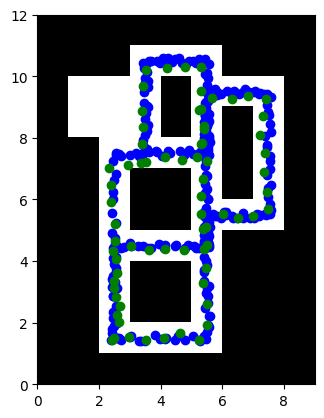

In [207]:
slam = GraphICPSLAM2DGTSAM(poses[0])
slam.step(scans[0][:, :2])
for i in range(1, len(scans)):
    # T, _, _ = icp(scans[i - 1][:, :2], scans[i][:, :2])

    slam.step(scans[i][:, :2])

slam.optimize()
opt_poses = slam.poses()

grid = m.free_space
plt.imshow(grid, origin='upper', cmap='gray', extent=(0, grid.shape[1], 0, grid.shape[0]))
plt.gca().set_aspect('equal')

def plot_pose(a, color='r', length=0.25):
    # dx = length * np.cos(a[2])
    # dy = length * np.sin(a[2])
    # plt.arrow(a[0], a[1], dx, dy, head_width=0.1, head_length=0.1, fc=color, ec=color)
    plt.scatter(a[0], a[1], c=color)

def plot_poses(poses, color='r', length=0.05):
    for i in range(poses.shape[0]):
        plot_pose(poses[i, :], color=color, length=length)


plot_poses(poses, 'b')
plot_poses(opt_poses, 'g')

# H = slam.hessian()
#
# plt.imshow(H, cmap='viridis', interpolation='nearest')
# plt.colorbar()  # Add a color bar to the side
# plt.title('Matrix Visualization')
# plt.show()
